This is part 14 of a tutorial series. We recommend reading [Part 12: Introduction to DAE Solving](12.%20dae_solving_intro.ipynb) and [Part 13: MIAM Processes and Constraints](13.%20miam_processes_and_constraints.ipynb) first.

# CAM Cloud Chemistry

In this tutorial, we bring everything together into a realistic cloud chemistry simulation modeled after the [Community Atmosphere Model (CAM)](https://www.cesm.ucar.edu/models/cam) cloud chemistry module. We'll simulate:

1. **Gas-phase precursor reactions** that produce SO₂ and H₂O₂
2. **Henry's Law partitioning** of SO₂, H₂O₂, and O₃ into cloud droplets
3. **Aqueous dissociation equilibria** (SO₂ → HSO₃⁻ → SO₃²⁻, H₂O → H⁺ + OH⁻)
4. **Sulfate production** via S(IV) oxidation by H₂O₂ and O₃
5. **Conservation laws** and **charge balance**

This is a complete, self-contained example of coupled gas-aqueous chemistry using MIAM's DAE solver.

## 1. Importing Libraries

In [1]:
import math
import musica
import musica.mechanism_configuration as mc
from musica.micm import MICM, SolverType, SolverState
from musica.miam import (
    HenrysLawConstant,
    EquilibriumConstant,
    ArrheniusRateConstant,
    UniformSection,
    DissolvedReaction,
    DissolvedReversibleReaction,
    HenryLawEquilibriumConstraint,
    DissolvedEquilibriumConstraint,
    LinearConstraint,
    LinearConstraintTerm,
    Model,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Physical Constants and Conditions

Cloud chemistry typically occurs at mid-tropospheric altitudes (~3–5 km) where temperatures are around 280 K and pressures around 700 hPa.

In [2]:
# Fundamental constants
R_GAS = 8.314                           # J/(mol·K)
T0 = 298.15                             # K (reference temperature)
M_ATM_TO_MOL_M3_PA = 1000.0 / 101325.0 # converts Henry's law from mol/(L·atm) to mol/(m³·Pa)
C_H2O_M = 55.556                        # mol/L — unit conversion constant for rate/eq constants
MW_H2O = 0.018                          # kg/mol
RHO_H2O = 1000.0                        # kg/m³

# Cloud liquid water content and derived solvent concentration
# All MIAM concentrations are in mol/m³ of AIR (including condensed-phase species).
# C_H2O_M (55.556 mol/L) is used ONLY for converting literature rate/equilibrium
# constants from molar (mol/L) units to MIAM (mol/m³) units.
LWC = 0.3e-3                            # kg/m³  (= 0.3 g/m³, typical cloud)
C_H2O = LWC / MW_H2O                    # mol/m³ of air  (≈ 0.01667)
f_v = C_H2O * MW_H2O / RHO_H2O          # liquid volume fraction (m³ liquid / m³ air)

# Atmospheric conditions
T_INIT = 280.0    # K (typical cloud temperature)
P_INIT = 70000.0  # Pa (typical cloud-level pressure, ~700 hPa)

# Conversion factor: mol/m³ of air ↔ mol/L of solution (aqueous-phase molarity)
# To get pH from [H+] in mol/m³: pH = -log10( [H+] / AIR_TO_SOLUTION )
AIR_TO_SOLUTION = f_v * 1000.0  # ≈ 3e-4; multiply mol/m³_air to get mol/L_solution

# Initial gas-phase concentrations (polluted boundary layer entering cloud)
GAS0_SO2 = 3.01e-7     # mol/m³ (~10 ppb SO2 — polluted scenario)
GAS0_H2O2 = 3.01e-7    # mol/m³ (~10 ppb H2O2)
GAS0_O3 = 1.5e-6       # mol/m³ (~50 ppb O3)
GAS0_DMS = 3.01e-8     # mol/m³ (~1 ppb DMS — moderate marine)
GAS0_OH = 3.01e-13     # mol/m³ (~0.01 ppt OH, typical daytime)

# Background sulfate from previous cloud processing
# ~3.3 mM in cloud water — represents a polluted continental cloud
SO4MM0 = 1e-6  # mol/m³ of air

print(f"Temperature: {T_INIT} K")
print(f"Pressure: {P_INIT/100:.0f} hPa")
print(f"LWC: {LWC*1e3:.1f} g/m³")
print(f"f_v: {f_v:.2e}")
print(f"AIR_TO_SOLUTION: {AIR_TO_SOLUTION:.2e}")
print(f"C_H2O (solvent): {C_H2O:.4f} mol/m³ of air")
print(f"SO2: ~{GAS0_SO2*R_GAS*T_INIT/P_INIT*1e9:.1f} ppb")
print(f"H2O2: ~{GAS0_H2O2*R_GAS*T_INIT/P_INIT*1e9:.1f} ppb")
print(f"O3:  ~{GAS0_O3*R_GAS*T_INIT/P_INIT*1e9:.0f} ppb")
print(f"Background SO4: {SO4MM0:.3e} mol/m³ of air ({SO4MM0/AIR_TO_SOLUTION*1e6:.0f} μM in cloud water)")
print(f"Expected initial pH: ~{-math.log10(2*SO4MM0 / AIR_TO_SOLUTION):.1f}")

Temperature: 280.0 K
Pressure: 700 hPa
LWC: 0.3 g/m³
f_v: 3.00e-07
AIR_TO_SOLUTION: 3.00e-04
C_H2O (solvent): 0.0167 mol/m³ of air
SO2: ~10.0 ppb
H2O2: ~10.0 ppb
O3:  ~50 ppb
Background SO4: 1.000e-06 mol/m³ of air (3333 μM in cloud water)
Expected initial pH: ~2.2


## 3. Gas-Phase Mechanism

We include three gas-phase processes:

1. **DMS + OH → SO₂**: Simplified dimethyl sulfide oxidation
2. **SO₂ emission → emitted\_SO₂**: Continuous pollution inflow into a dummy tracking species
3. **H₂O₂ emission**: Photochemical H₂O₂ production

The SO₂ emission targets a **dummy species** (`emitted_SO2`) rather than SO₂(g) directly. This is necessary because the S(IV) mass conservation constraint makes SO₂(g) algebraic — if the emission targeted SO₂(g), the constraint would overwrite the emitted amount at every solver stage. Instead, the constraint includes `emitted_SO2` with coefficient −1, so as it accumulates, SO₂(g) grows to maintain the balance.

In [3]:
# ── Gas-phase species ──
so2_g = mc.Species(name="SO2")
h2o2_g = mc.Species(name="H2O2")
o3_g = mc.Species(name="O3")
dms = mc.Species(name="DMS")
oh = mc.Species(name="OH")

# Dummy tracking species for SO2 emission.
# The S(IV) mass conservation constraint makes SO2(g) algebraic, so we cannot
# use a MICM Emission reaction that targets SO2(g) directly — the constraint
# would overwrite the emitted amount each solver stage.  Instead, the emission
# produces this dummy species, and the constraint includes it with coefficient -1.
# As emitted_SO2 grows, SO2(g) (algebraic) increases to keep the balance.
emitted_so2 = mc.Species(name="emitted_SO2")

gas = mc.Phase(name="gas", species=[so2_g, h2o2_g, o3_g, dms, oh, emitted_so2])

# DMS + OH → SO2  (simplified — real mechanism is more complex)
dms_oxidation = mc.UserDefined(
    name="DMS_OH_to_SO2",
    scaling_factor=1.0,
    reactants=[dms, oh],
    products=[so2_g],
    gas_phase=gas,
)

# SO2 emission → emitted_SO2 (dummy tracker)
so2_source = mc.Emission(
    name="SO2_source",
    scaling_factor=1.0,
    products=[emitted_so2],
    gas_phase=gas,
)

# H2O2 emission (constant source representing photochemistry)
h2o2_source = mc.Emission(
    name="H2O2_source",
    scaling_factor=1.0,
    products=[h2o2_g],
    gas_phase=gas,
)

gas_mechanism = mc.Mechanism(
    name="cloud_precursors",
    species=[so2_g, h2o2_g, o3_g, dms, oh, emitted_so2],
    phases=[gas],
    reactions=[dms_oxidation, so2_source, h2o2_source],
)

print("Gas-phase mechanism:")
for rxn in gas_mechanism.reactions:
    print(f"  [{rxn.type.name}] {rxn.to_equation()}")

Gas-phase mechanism:
  [Emission] -> emitted_SO2
  [Emission] -> H2O2
  [UserDefined] DMS + OH -> SO2


## 4. MIAM Model: Aqueous Phase

The MIAM model defines the condensed-phase species, representation, processes, and constraints. This is the heart of the CAM cloud chemistry.

### 4a. Aqueous Species

The aqueous phase contains:
- **Dissolved gases**: SO₂(aq), H₂O₂(aq), O₃(aq)
- **Dissociation products**: H⁺, OH⁻, HSO₃⁻, SO₃²⁻
- **Oxidation product**: SO₄²⁻
- **Solvent**: H₂O

In [4]:
# ── Aqueous species ──
h2o = mc.Species(name="H2O")
h2o.molecular_weight_kg_mol = MW_H2O
h2o.density_kg_m3 = RHO_H2O

so2_aq = mc.Species(name="SO2_aq")
h2o2_aq = mc.Species(name="H2O2_aq")
o3_aq = mc.Species(name="O3_aq")
hp = mc.Species(name="Hp")         # H+
ohm = mc.Species(name="OHm")       # OH-
hso3m = mc.Species(name="HSO3m")   # HSO3-
so3mm = mc.Species(name="SO3mm")   # SO3²-
so4mm = mc.Species(name="SO4mm")   # SO4²-
so2oohm = mc.Species(name="SO2OOHm")  # SO2OOH- (intermediate)

aq_phase = mc.Phase(
    name="AQUEOUS",
    species=[h2o, so2_aq, h2o2_aq, o3_aq, hp, ohm, hso3m, so3mm, so4mm, so2oohm],
)

# All species (gas + aqueous) — needed by the MIAM Model
all_species = [
    so2_g, h2o2_g, o3_g, dms, oh, emitted_so2,
    so2_aq, h2o2_aq, o3_aq, hp, ohm, hso3m, so3mm, so4mm, so2oohm, h2o,
]

print(f"Total species: {len(all_species)} ({6} gas + {10} aqueous)")

Total species: 16 (6 gas + 10 aqueous)


### 4b. Cloud Droplet Representation

In [5]:
cloud = UniformSection(
    name="CLOUD",
    phase_names=["AQUEOUS"],
    min_radius=1e-6,    # 1 μm
    max_radius=1e-5,    # 10 μm
)
print(f"Cloud droplets: {cloud.min_radius*1e6:.0f}–{cloud.max_radius*1e6:.0f} μm radius")

Cloud droplets: 1–10 μm radius


### 4c. Aqueous-Phase Oxidation Reactions

The key sulfate-production reactions in cloud water use the revised 2-step H₂O₂ mechanism via the SO₂OOH⁻ intermediate (Lind & Kok, 1986):

| # | Reaction | Type | Rate / Keq | Ea/R (K) |
|---|---|---|---|---|
| R1a | HSO₃⁻ + H₂O₂(aq) ⇌ SO₂OOH⁻ + H₂O | Reversible | k_fwd = 7.45×10⁷/13 M⁻¹s⁻¹, K_eq = 1725 | 4430 |
| R1b | SO₂OOH⁻ + H⁺ → SO₄²⁻ | Irreversible | 2.4×10⁶ M⁻¹s⁻¹ | 4430 |
| R2 | HSO₃⁻ + O₃(aq) → SO₄²⁻ + H⁺ | Irreversible | 3.75×10⁵ M⁻¹s⁻¹ | 5530 |
| R3 | SO₃²⁻ + O₃(aq) → SO₄²⁻ | Irreversible | 1.59×10⁹ M⁻¹s⁻¹ | 5280 |

The H₂O₂ pathway (R1a+R1b) dominates at low pH, while R2/R3 (the O₃ pathway) are important at higher pH where more S(IV) is in the HSO₃⁻ and SO₃²⁻ forms.

In [6]:
# R1a: HSO3- + H2O2(aq) ⇌ SO2OOH- + H2O  (reversible)
r1a = DissolvedReversibleReaction(
    phase_name="AQUEOUS",
    reactant_names=["HSO3m", "H2O2_aq"],
    product_names=["SO2OOHm", "H2O"],
    solvent_name="H2O",
    forward_rate_constant=ArrheniusRateConstant(
        a=C_H2O_M * (7.45e7 / 13.0), c=4430.0),
    equilibrium_constant=EquilibriumConstant(a=1725.0),
)

# R1b: SO2OOH- + H+ → SO4²-  (irreversible)
r1b = DissolvedReaction(
    phase_name="AQUEOUS",
    reactant_names=["SO2OOHm", "Hp"],
    product_names=["SO4mm"],
    solvent_name="H2O",
    rate_constant=ArrheniusRateConstant(a=C_H2O_M * 2.4e6, c=4430.0),
    max_halflife=1.0,  # cap rate so no reactant depleted faster than 1 s half-life
)

# R2: HSO3- + O3(aq) → SO4²- + H+
r2 = DissolvedReaction(
    phase_name="AQUEOUS",
    reactant_names=["HSO3m", "O3_aq"],
    product_names=["SO4mm", "Hp"],
    solvent_name="H2O",
    rate_constant=ArrheniusRateConstant(a=C_H2O_M * 3.75e5, c=5530.0),
    max_halflife=1.0,
)

# R3: SO3²- + O3(aq) → SO4²-
r3 = DissolvedReaction(
    phase_name="AQUEOUS",
    reactant_names=["SO3mm", "O3_aq"],
    product_names=["SO4mm"],
    solvent_name="H2O",
    rate_constant=ArrheniusRateConstant(a=C_H2O_M * 1.59e9, c=5280.0),
    max_halflife=1.0,
)

print("Aqueous oxidation reactions defined:")
print("  R1a: HSO3- + H2O2(aq) ⇌ SO2OOH- + H2O  (reversible, Keq=1725)")

print("  R1b: SO2OOH- + H+ → SO4²-")
print("  R2:  HSO3- + O3(aq) → SO4²- + H+")
print("  R3:  SO3²- + O3(aq) → SO4²-")

Aqueous oxidation reactions defined:
  R1a: HSO3- + H2O2(aq) ⇌ SO2OOH- + H2O  (reversible, Keq=1725)
  R1b: SO2OOH- + H+ → SO4²-
  R2:  HSO3- + O3(aq) → SO4²- + H+
  R3:  SO3²- + O3(aq) → SO4²-


### 4d. Constraints

The constraint system couples the gas and aqueous phases and enforces thermodynamic consistency. We use 10 constraints:

| Type | Equation | Algebraic species |
|---|---|---|
| Henry's Law | SO₂(aq) = α × SO₂(g) | SO₂(aq) |
| Henry's Law | H₂O₂(aq) = α × H₂O₂(g) | H₂O₂(aq) |
| Henry's Law | O₃(aq) = α × O₃(g) | O₃(aq) |
| Dissociation | Kw: H₂O ⇌ H⁺ + OH⁻ | OH⁻ |
| Dissociation | Ka1: SO₂(aq) ⇌ HSO₃⁻ + H⁺ | HSO₃⁻ |
| Dissociation | Ka2: HSO₃⁻ ⇌ SO₃²⁻ + H⁺ | SO₃²⁻ |
| Mass conservation | Total S = SO₂(g) + SO₂(aq) + HSO₃⁻ + SO₃²⁻ + SO₄²⁻ + SO₂OOH⁻ − emitted_SO₂ | SO₂(g) |
| Mass conservation | Total H₂O₂ = H₂O₂(g) + H₂O₂(aq) | H₂O₂(g) |
| Mass conservation | Total O₃ = O₃(g) + O₃(aq) | O₃(g) |
| Charge balance | H⁺ = OH⁻ + HSO₃⁻ + 2SO₃²⁻ + 2SO₄²⁻ + SO₂OOH⁻ | H⁺ |

Note that the total sulfur constraint **includes SO₄²⁻** — this ensures exact sulfur conservation. As SO₄²⁻ accumulates from the oxidation reactions, the algebraic SO₂(g) decreases by the same amount.

In [7]:
constraints = []

# ── Henry's Law equilibria ──
# K_H values from Sander (2015), converted to mol/(m³·Pa)
henry_law_species = [
    ("SO2",  "SO2_aq",  1.23,    3120.0),   # K_H = 1.23 mol/(L·atm)
    ("H2O2", "H2O2_aq", 7.4e4,   6621.0),   # K_H = 7.4e4 mol/(L·atm)
    ("O3",   "O3_aq",   1.15e-2, 2560.0),   # K_H = 1.15e-2 mol/(L·atm)
]

for gas_name, aq_name, hlc_ref_lit, c in henry_law_species:
    constraints.append(HenryLawEquilibriumConstraint(
        gas_species_name=gas_name,
        condensed_species_name=aq_name,
        solvent_name="H2O",
        condensed_phase_name="AQUEOUS",
        henrys_law_constant=HenrysLawConstant(
            hlc_ref=hlc_ref_lit * M_ATM_TO_MOL_M3_PA,  # convert to mol/(m³·Pa)
            c=c,
        ),
        mw_solvent=MW_H2O,
        rho_solvent=RHO_H2O,
    ))

# ── Dissociation equilibria ──
# Kw: H2O ⇌ H+ + OH-     (Kw = 1e-14 M²)
constraints.append(DissolvedEquilibriumConstraint(
    phase_name="AQUEOUS",
    reactant_names=["H2O"],
    product_names=["Hp", "OHm"],
    algebraic_species_name="OHm",
    solvent_name="H2O",
    equilibrium_constant=EquilibriumConstant(
        a=1e-14 / (C_H2O_M * C_H2O_M), c=0.0),
))

# Ka1: SO2(aq) ⇌ HSO3- + H+   (Ka1 = 1.7e-2 M)
constraints.append(DissolvedEquilibriumConstraint(
    phase_name="AQUEOUS",
    reactant_names=["SO2_aq"],
    product_names=["HSO3m", "Hp"],
    algebraic_species_name="HSO3m",
    solvent_name="H2O",
    equilibrium_constant=EquilibriumConstant(a=1.7e-2 / C_H2O_M, c=2090.0),
))

# Ka2: HSO3- ⇌ SO3²- + H+   (Ka2 = 6.0e-8 M)
constraints.append(DissolvedEquilibriumConstraint(
    phase_name="AQUEOUS",
    reactant_names=["HSO3m"],
    product_names=["SO3mm", "Hp"],
    algebraic_species_name="SO3mm",
    solvent_name="H2O",
    equilibrium_constant=EquilibriumConstant(a=6.0e-8 / C_H2O_M, c=1120.0),
))

# ── Mass conservation ──
# Total sulfur: includes all sulfur species, including SO₄²⁻.
# SO₂(g) is the algebraic variable — it is computed from the budget:
#   SO₂(g) = C_total + emitted_SO₂ − (SO₂_aq + HSO₃⁻ + SO₃²⁻ + SO₂OOH⁻ + SO₄²⁻)
# The dummy emitted_SO₂ species (coefficient −1) lets MICM SO₂ emissions
# feed into the mass budget.
constraints.append(LinearConstraint(
    algebraic_phase_name="gas",
    algebraic_species_name="SO2",
    terms=[
        LinearConstraintTerm("gas", "SO2", 1.0),
        LinearConstraintTerm("AQUEOUS", "SO2_aq", 1.0),
        LinearConstraintTerm("AQUEOUS", "HSO3m", 1.0),
        LinearConstraintTerm("AQUEOUS", "SO3mm", 1.0),
        LinearConstraintTerm("AQUEOUS", "SO2OOHm", 1.0),
        LinearConstraintTerm("AQUEOUS", "SO4mm", 1.0),
        LinearConstraintTerm("gas", "emitted_SO2", -1.0),
    ],
    diagnose_from_state=True,
))

# Total H2O2
constraints.append(LinearConstraint(
    algebraic_phase_name="gas",
    algebraic_species_name="H2O2",
    terms=[
        LinearConstraintTerm("gas", "H2O2", 1.0),
        LinearConstraintTerm("AQUEOUS", "H2O2_aq", 1.0),
    ],
    diagnose_from_state=True,
))

# Total O3
constraints.append(LinearConstraint(
    algebraic_phase_name="gas",
    algebraic_species_name="O3",
    terms=[
        LinearConstraintTerm("gas", "O3", 1.0),
        LinearConstraintTerm("AQUEOUS", "O3_aq", 1.0),
    ],
    diagnose_from_state=True,
))

# ── Charge balance ──
# H+ = OH- + HSO3- + 2×SO3²- + 2×SO4²- + SO2OOH-
constraints.append(LinearConstraint(
    algebraic_phase_name="AQUEOUS",
    algebraic_species_name="Hp",
    terms=[
        LinearConstraintTerm("AQUEOUS", "Hp", 1.0),
        LinearConstraintTerm("AQUEOUS", "OHm", -1.0),
        LinearConstraintTerm("AQUEOUS", "HSO3m", -1.0),
        LinearConstraintTerm("AQUEOUS", "SO3mm", -2.0),
        LinearConstraintTerm("AQUEOUS", "SO4mm", -2.0),
        LinearConstraintTerm("AQUEOUS", "SO2OOHm", -1.0),
    ],
    constant=0.0,
))

print(f"Constraints defined: {len(constraints)} total")
print(f"  3 Henry's Law, 3 dissociation, 3 mass conservation, 1 charge balance")

Constraints defined: 10 total
  3 Henry's Law, 3 dissociation, 3 mass conservation, 1 charge balance


### 4e. Assembling the MIAM Model

In [8]:
miam_model = Model(
    name="cam_cloud_chemistry",
    species=all_species,
    condensed_phases=[aq_phase],
    representations=[cloud],
    processes=[r1a, r1b, r2, r3],
    constraints=constraints,
)

print("MIAM model assembled:")
print(f"  Species: {len(all_species)}")
print(f"  Processes: {len(miam_model.processes)}")
print(f"  Constraints: {len(miam_model.constraints)}")

MIAM model assembled:
  Species: 16
  Processes: 4
  Constraints: 10


## 5. Creating the Coupled Solver

We create a single MICM solver that integrates both the gas-phase reactions (from the mechanism) and the aqueous chemistry (from the MIAM model) as a unified DAE system.

In [9]:
from musica.micm.solver_parameters import RosenbrockSolverParameters

micm = MICM(
    mechanism=gas_mechanism,
    solver_type=SolverType.rosenbrock_dae4_standard_order,
    external_models=[miam_model],
)

# ── Set per-species absolute tolerances ──
# The DAE solver uses step-change error estimation for algebraic variables:
#   Yerror[a] = Ynew[a] - Y[a]
# This means algebraic tolerances directly control step acceptance.
# MICM developer guide recommends 1e-8 to 1e-10 for algebraic species.
tmp_state = micm.create_state()
ordering = tmp_state.get_species_ordering()

abs_tols = [1e-3] * len(ordering)  # default for non-constrained gas-phase species
for name, idx in ordering.items():
    if "CLOUD.AQUEOUS." in name:
        abs_tols[idx] = 1e-8
    elif name in ("SO2", "H2O2", "O3"):
        abs_tols[idx] = 1e-9  # gas-phase algebraic species: slightly tighter

micm.set_solver_parameters(RosenbrockSolverParameters(
    absolute_tolerances=abs_tols,
    constraint_init_max_iterations=100,
    constraint_init_tolerance=1e-8,
    max_number_of_steps=200000,
))

# Now create the real state with proper tolerances baked in
state = micm.create_state()
miam_model.set_default_parameters(state)
state.set_conditions(temperatures=T_INIT, pressures=P_INIT)

print(f"Solver type: {micm.solver_type().name}")
print(f"Species ordering: {ordering}")
print(f"\nAbsolute tolerances:")
for name, idx in sorted(ordering.items(), key=lambda x: x[1]):
    print(f"  [{idx:2d}] {name:40s}  atol={abs_tols[idx]:.0e}")
print(f"\nState created successfully.")

Solver type: rosenbrock_dae4_standard_order
Species ordering: {'CLOUD.AQUEOUS.HSO3m': 14, 'CLOUD.AQUEOUS.H2O': 13, 'H2O2': 0, 'O3': 1, 'DMS': 5, 'CLOUD.AQUEOUS.OHm': 3, 'emitted_SO2': 2, 'CLOUD.AQUEOUS.SO2_aq': 4, 'CLOUD.AQUEOUS.SO4mm': 15, 'OH': 7, 'CLOUD.AQUEOUS.SO3mm': 8, 'CLOUD.AQUEOUS.SO2OOHm': 12, 'SO2': 6, 'CLOUD.AQUEOUS.O3_aq': 9, 'CLOUD.AQUEOUS.Hp': 10, 'CLOUD.AQUEOUS.H2O2_aq': 11}

Absolute tolerances:
  [ 0] H2O2                                      atol=1e-09
  [ 1] O3                                        atol=1e-09
  [ 2] emitted_SO2                               atol=1e-03
  [ 3] CLOUD.AQUEOUS.OHm                         atol=1e-08
  [ 4] CLOUD.AQUEOUS.SO2_aq                      atol=1e-08
  [ 5] DMS                                       atol=1e-03
  [ 6] SO2                                       atol=1e-09
  [ 7] OH                                        atol=1e-03
  [ 8] CLOUD.AQUEOUS.SO3mm                       atol=1e-08
  [ 9] CLOUD.AQUEOUS.O3_aq                  

### 5a. Solver Tuning: Tolerances, Damping, and Rate Capping

Three optional settings let you tune solver behavior for stiff aqueous chemistry:

**Absolute tolerances** — Per-species error thresholds for the Rosenbrock step-acceptance criterion. The DAE solver checks errors on *all* variables — both differential (kinetic) and algebraic (constraint-derived). Aqueous species in mol/m³ of air are many orders of magnitude smaller than gas-phase species, so they need much tighter absolute tolerances. Algebraic gas-phase variables (SO₂, H₂O₂, O₃) should have tolerances appropriate for their expected range to prevent the solver from accepting steps where a conservation-balance variable overshoots through zero.

**Solvent damping epsilon** — Controls a regularization factor in the rate expression: `rate = k * [S] / ([S] + eps)^n_r`. This prevents division-by-zero when the solvent concentration approaches zero. The default value is 1.0e-20.

**Rate capping (max_halflife)** — When set on a `DissolvedReaction`, smoothly caps the reaction rate so that no reactant is consumed faster than the specified half-life (in seconds). This prevents the solver from needing impractically small timesteps for extremely fast reactions. The cap uses a `tanh` function for C¹ smoothness, so the Jacobian remains well-behaved. Set to 0 (default) to disable.

In [10]:
# Example: customizing solvent_damping_epsilon (default is 1e-20)
# This is only needed if you have very dilute cloud conditions.
print(f"R1a solvent_damping_epsilon: {r1a.solvent_damping_epsilon}")
print(f"R1b solvent_damping_epsilon: {r1b.solvent_damping_epsilon}")

# Rate capping with max_halflife
# When enabled, the rate is smoothly capped: rate_capped = r_max * tanh(rate / r_max)
# where r_max = C_min / max_halflife (C_min = soft-min of reactant concentrations)
print(f"R1b max_halflife: {r1b.max_halflife} s")
print(f"R2  max_halflife: {r2.max_halflife} s")
print(f"R3  max_halflife: {r3.max_halflife} s")

R1a solvent_damping_epsilon: 1e-20
R1b solvent_damping_epsilon: 1e-20
R1b max_halflife: 1.0 s
R2  max_halflife: 1.0 s
R3  max_halflife: 1.0 s


## 6. Initial Conditions

The MICM DAE solver automatically runs a Newton iteration on the algebraic variables at the start of each `solve()` call, projecting them onto the constraint manifold. This means we only need to provide reasonable guesses for the initial concentrations — the solver will correct them.

In [11]:
# Simple initial guesses — the solver's constraint initialization will
# adjust all algebraic variables (aqueous species, H+, etc.) to satisfy
# the constraint equations before time-stepping begins.
ics = {
    "SO2": GAS0_SO2,
    "H2O2": GAS0_H2O2,
    "O3": GAS0_O3,
    "DMS": GAS0_DMS,
    "OH": GAS0_OH,
    "emitted_SO2": 0.0,  # starts at zero — accumulates during simulation
    "CLOUD.AQUEOUS.H2O": C_H2O,
    "CLOUD.AQUEOUS.SO2_aq": 1e-12,
    "CLOUD.AQUEOUS.H2O2_aq": 1e-12,
    "CLOUD.AQUEOUS.O3_aq": 1e-14,
    "CLOUD.AQUEOUS.Hp": 2.0 * SO4MM0,  # from charge balance: [H+] ≈ 2[SO4²⁻]
    "CLOUD.AQUEOUS.OHm": 1e-14,
    "CLOUD.AQUEOUS.HSO3m": 1e-12,
    "CLOUD.AQUEOUS.SO3mm": 1e-16,
    "CLOUD.AQUEOUS.SO4mm": SO4MM0,
    "CLOUD.AQUEOUS.SO2OOHm": 0.0,
}

state.set_concentrations(ics)

print("Initial conditions (before constraint initialization):")
print(f"  SO2(g):       {ics['SO2']:.3e} mol/m³  (~{GAS0_SO2*R_GAS*T_INIT/P_INIT*1e9:.0f} ppb)")
print(f"  H2O2(g):      {ics['H2O2']:.3e} mol/m³")
print(f"  SO4²-:        {ics['CLOUD.AQUEOUS.SO4mm']:.3e} mol/m³")
print(f"  emitted_SO2:  {ics['emitted_SO2']:.1f}")
print(f"  H+(guess):    {ics['CLOUD.AQUEOUS.Hp']:.3e} mol/m³")
print(f"  H2O:          {ics['CLOUD.AQUEOUS.H2O']:.4f} mol/m³ of air")

Initial conditions (before constraint initialization):
  SO2(g):       3.010e-07 mol/m³  (~10 ppb)
  H2O2(g):      3.010e-07 mol/m³
  SO4²-:        1.000e-06 mol/m³
  emitted_SO2:  0.0
  H+(guess):    2.000e-06 mol/m³
  H2O:          0.0167 mol/m³ of air


## 7. Setting Gas-Phase Rate Parameters

The `UserDefined` and `Emission` reactions require us to set their rates externally. These stay constant throughout the simulation.

In [12]:
# DMS + OH rate constant: k = 1.1e-11 × exp(-240/T) cm³/(molec·s)
# Convert to mol/m³ basis (MICM convention)
k_dms = 1.1e-11 * math.exp(-240.0 / T_INIT)  # cm³/(molec·s)
k_dms_musica = k_dms * 6.022e23 * 1e-6  # m³/(mol·s)

# SO2 emission (into dummy tracker species → fed to SO2(g) via constraint)
emis_so2 = 3e-10  # mol/(m³·s) — ~10 ppb/hr inflow rate

# H2O2 emission: photochemical production
emis_h2o2 = 5e-11  # mol/(m³·s) — replenishes H2O2 consumed by oxidation

state.set_user_defined_rate_parameters({
    "USER.DMS_OH_to_SO2": k_dms_musica,
    "EMIS.SO2_source": emis_so2,
    "EMIS.H2O2_source": emis_h2o2,
})

print(f"DMS+OH rate constant: {k_dms_musica:.2e} m³/(mol·s)")
print(f"SO2  emission rate:   {emis_so2:.2e} mol/(m³·s)")
print(f"H2O2 emission rate:   {emis_h2o2:.2e} mol/(m³·s)")

DMS+OH rate constant: 2.81e+06 m³/(mol·s)
SO2  emission rate:   3.00e-10 mol/(m³·s)
H2O2 emission rate:   5.00e-11 mol/(m³·s)


## 8. Running the Simulation

We simulate 2 hours (7200 seconds) of cloud processing with 30-second output steps.

In [13]:
# ── Integration loop ──
target_time = 7200.0   # 2 hours
output_interval = 30.0 # Record every 30 s

# Collect results
times = [0.0]
results = [state.get_concentrations()]
step_counts = []  # solver internal steps per output interval

total_time = 0.0

while total_time < target_time - 1e-10:
    dt = min(output_interval, target_time - total_time)
    result = micm.solve(state, time_step=dt)
    assert result.state == SolverState.Converged, \
        f"Solver failed at t={total_time:.4f}s (state={result.state})"
    total_time += dt

    times.append(total_time)
    results.append(state.get_concentrations())
    step_counts.append(result.stats.accepted + result.stats.rejected)

print(f"Simulation complete: {total_time:.0f} s ({total_time/60:.0f} minutes)")
print(f"Output timesteps: {len(times)}")
print(f"Total solver steps: {sum(step_counts)} (avg {np.mean(step_counts):.1f}/interval)")

Simulation complete: 7200 s (120 minutes)
Output timesteps: 241
Total solver steps: 3295 (avg 13.7/interval)


## 9. Results: Time Series

Let's visualize the key quantities: gas-phase SO₂ depletion, sulfate production, and pH evolution.

In [14]:
# Extract time series for key species
# Skip t=0 (pre-constraint-initialization values are not physically consistent)
def extract_series(name):
    return np.array([r[name][0] for r in results[1:]])

t = np.array(times[1:])
so2_g_ts = extract_series("SO2")
so4_ts = extract_series("CLOUD.AQUEOUS.SO4mm")
hp_ts = extract_series("CLOUD.AQUEOUS.Hp")
h2o2_g_ts = extract_series("H2O2")
so2_aq_ts = extract_series("CLOUD.AQUEOUS.SO2_aq")
hso3_ts = extract_series("CLOUD.AQUEOUS.HSO3m")
so3_ts = extract_series("CLOUD.AQUEOUS.SO3mm")
so2ooh_ts = extract_series("CLOUD.AQUEOUS.SO2OOHm")
dms_ts = extract_series("DMS")
o3_g_ts = extract_series("O3")
ohm_ts = extract_series("CLOUD.AQUEOUS.OHm")
emitted_so2_ts = extract_series("emitted_SO2")

# Convert H+ (mol/m³ of air) to aqueous-phase pH
# [H+]_molarity = [H+]_air / (f_v * 1000)
# pH = -log10( [H+]_air / AIR_TO_SOLUTION )
pH_ts = -np.log10(hp_ts / AIR_TO_SOLUTION)

# Diagnostics
print(f"SO2(g):      min={so2_g_ts.min():.3e}  max={so2_g_ts.max():.3e}")
print(f"SO2(aq):     min={so2_aq_ts.min():.3e}  max={so2_aq_ts.max():.3e}")
print(f"SO4:         min={so4_ts.min():.3e}  max={so4_ts.max():.3e}")
print(f"pH:          min={pH_ts.min():.2f}  max={pH_ts.max():.2f}")
print(f"emitted_SO2: min={emitted_so2_ts.min():.3e}  max={emitted_so2_ts.max():.3e}")
print(f"H2O2(g):     min={h2o2_g_ts.min():.3e}  max={h2o2_g_ts.max():.3e}")
f_v_check = 0.01667 * 0.018 / 1000.0
print(f"aq/g ratio at t=0: {so2_aq_ts[0]/so2_g_ts[0]:.6e}")
print(f"Expected alpha:    {2.3921e-02 * 8.314 * 280.0 * f_v_check:.6e}")

SO2(g):      min=1.586e-07  max=2.308e-06
SO2(aq):     min=2.650e-12  max=3.856e-11
SO4:         min=1.080e-06  max=1.153e-06
pH:          min=2.11  max=2.13
emitted_SO2: min=9.000e-09  max=2.160e-06
H2O2(g):     min=9.550e-08  max=9.550e-08
aq/g ratio at t=0: 1.670695e-05
Expected alpha:    1.670919e-05


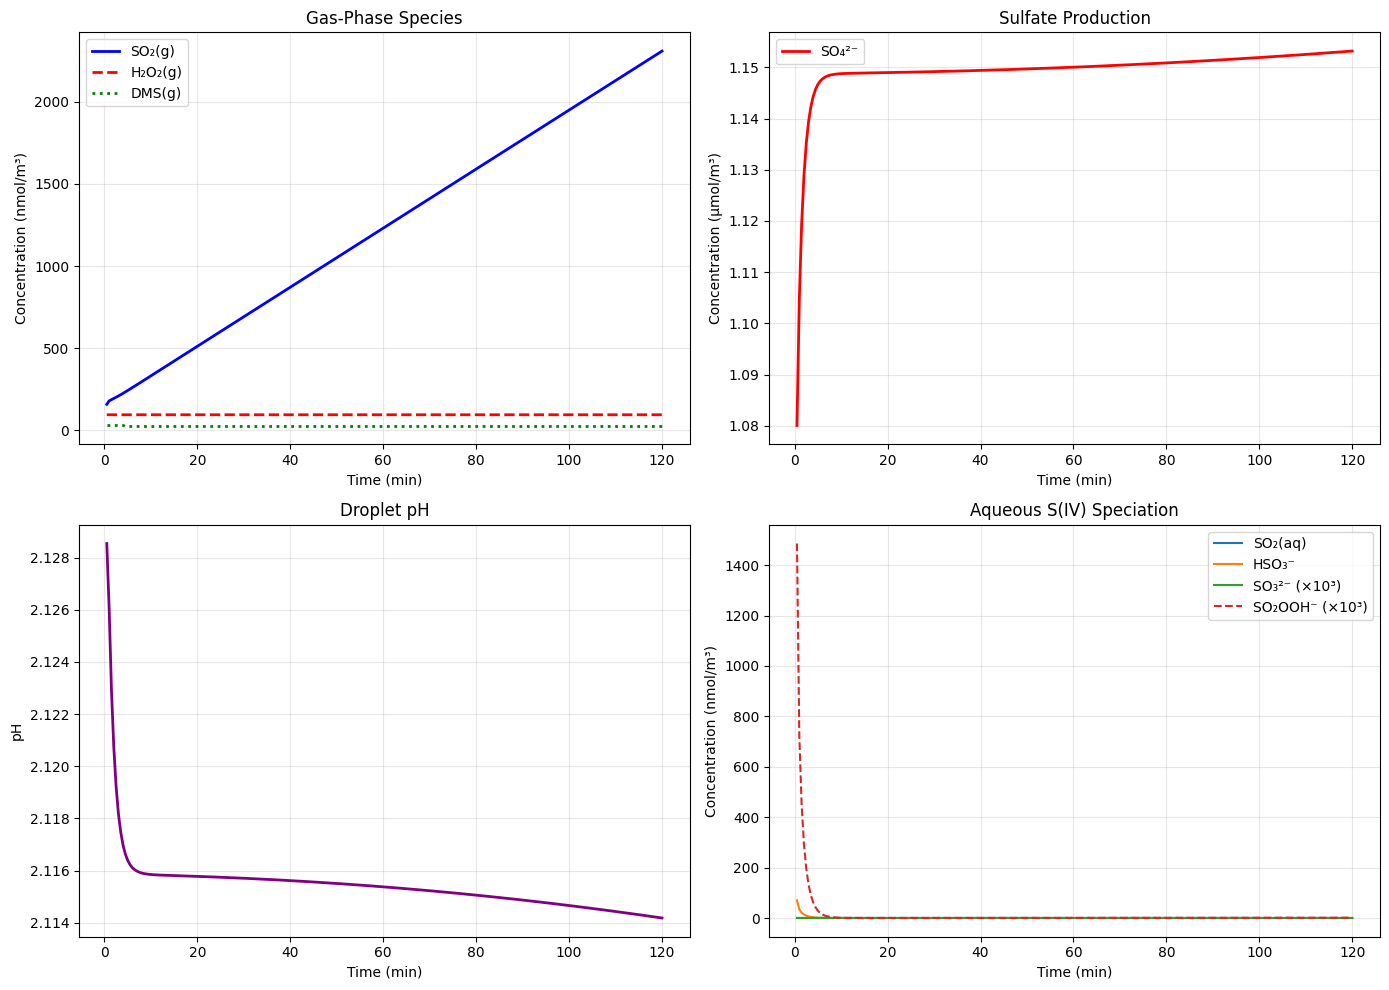

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
t_min = t / 60  # convert to minutes

# Panel 1: Gas-phase SO2 and oxidants
ax = axes[0, 0]
ax.plot(t_min, so2_g_ts * 1e9, 'b-', linewidth=2, label='SO₂(g)')
ax.plot(t_min, h2o2_g_ts * 1e9, 'r--', linewidth=2, label='H₂O₂(g)')
ax.plot(t_min, dms_ts * 1e9, 'g:', linewidth=2, label='DMS(g)')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Concentration (nmol/m³)')
ax.set_title('Gas-Phase Species')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Sulfate production
ax = axes[0, 1]
ax.plot(t_min, so4_ts * 1e6, 'r-', linewidth=2, label='SO₄²⁻')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Concentration (μmol/m³)')
ax.set_title('Sulfate Production')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: pH evolution
ax = axes[1, 0]
ax.plot(t_min, pH_ts, 'purple', linewidth=2)
ax.set_xlabel('Time (min)')
ax.set_ylabel('pH')
ax.set_title('Droplet pH')
ax.grid(True, alpha=0.3)

# Panel 4: S(IV) speciation in aqueous phase
ax = axes[1, 1]
ax.plot(t_min, so2_aq_ts * 1e9, label='SO₂(aq)', linewidth=1.5)
ax.plot(t_min, hso3_ts * 1e9, label='HSO₃⁻', linewidth=1.5)
ax.plot(t_min, so3_ts * 1e12, label='SO₃²⁻ (×10³)', linewidth=1.5)
ax.plot(t_min, so2ooh_ts * 1e12, '--', label='SO₂OOH⁻ (×10³)', linewidth=1.5)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Concentration (nmol/m³)')
ax.set_title('Aqueous S(IV) Speciation')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Validation: Conservation Laws and Equilibria

Let's verify that the solver maintains exact sulfur conservation, charge balance, and Henry's Law equilibrium throughout the simulation.

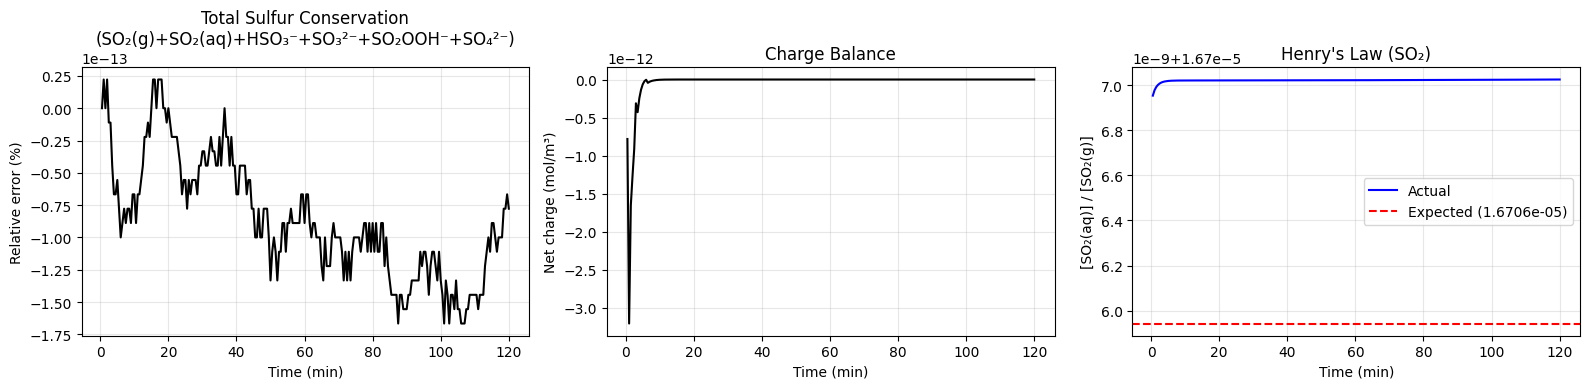

Max charge imbalance:          3.21e-12 mol/m³
Max Henry's Law error:         6.48e-05
Max total-S conservation err:  1.67e-15
SO₂(g) always positive:        True
SO₂(g) min value:              1.5861e-07 mol/m³


In [16]:
# ── Total sulfur conservation ──
# With the total-S constraint, sulfur is exactly conserved:
#   SO₂(g) + SO₂(aq) + HSO₃⁻ + SO₃²⁻ + SO₂OOH⁻ + SO₄²⁻ - emitted_SO₂ = C
total_S_ts = so2_g_ts + so2_aq_ts + hso3_ts + so3_ts + so2ooh_ts + so4_ts
total_S_expected = total_S_ts[0] + (emitted_so2_ts - emitted_so2_ts[0])

# ── Charge balance ──
charge_ts = hp_ts - ohm_ts - hso3_ts - 2*so3_ts - 2*so4_ts - so2ooh_ts

# ── Henry's Law ratio for SO2 ──
hlc_T = (1.23 * M_ATM_TO_MOL_M3_PA) * math.exp(3120.0 * (1.0/T_INIT - 1.0/T0))
alpha_expected = hlc_T * R_GAS * T_INIT * f_v
alpha_actual = so2_aq_ts / np.where(so2_g_ts > 0, so2_g_ts, 1e-30)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
t_min = t / 60

# Total sulfur conservation
ax = axes[0]
ax.plot(t_min, (total_S_ts / total_S_expected - 1) * 100, 'k-', linewidth=1.5)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Relative error (%)')
ax.set_title('Total Sulfur Conservation\n(SO₂(g)+SO₂(aq)+HSO₃⁻+SO₃²⁻+SO₂OOH⁻+SO₄²⁻)')
ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(-3,3))

# Charge balance
ax = axes[1]
ax.plot(t_min, charge_ts, 'k-', linewidth=1.5)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Net charge (mol/m³)')
ax.set_title('Charge Balance')
ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(-3,3))

# Henry's Law ratio
ax = axes[2]
ax.plot(t_min, alpha_actual, 'b-', linewidth=1.5, label='Actual')
ax.axhline(y=alpha_expected, color='red', linestyle='--', label=f'Expected ({alpha_expected:.4e})')
ax.set_xlabel('Time (min)')
ax.set_ylabel('[SO₂(aq)] / [SO₂(g)]')
ax.set_title("Henry's Law (SO₂)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"Max charge imbalance:          {abs(charge_ts).max():.2e} mol/m³")
print(f"Max Henry's Law error:         {abs(alpha_actual/alpha_expected - 1).max():.2e}")
print(f"Max total-S conservation err:  {abs(total_S_ts/total_S_expected - 1).max():.2e}")
print(f"SO₂(g) always positive:        {(so2_g_ts > 0).all()}")
print(f"SO₂(g) min value:              {so2_g_ts.min():.4e} mol/m³")

## 11. Discussion: The Self-Limiting Mechanism

The results illustrate the classical **self-limiting mechanism** of cloud sulfate production:

1. **SO₂ emission continuously injects fresh SO₂** into the system
2. **Aqueous oxidation** (primarily HSO₃⁻ + H₂O₂ at low pH, SO₃²⁻ + O₃ at high pH) converts S(IV) to sulfate
3. **SO₄²⁻ increases steadily**, producing H⁺ (acid) — the pH drops by several units over the 2-hour simulation
4. **Lower pH shifts S(IV) speciation** toward SO₂(aq) and away from HSO₃⁻/SO₃²⁻
5. Since the oxidation reactions consume HSO₃⁻ and SO₃²⁻ (not SO₂(aq) directly), **the oxidation rate decreases** as the cloud becomes more acidic

This negative feedback is correctly captured by the DAE solver because the pH (via the charge balance constraint) is coupled to the kinetics at every solver stage. With process splitting, this feedback would be delayed by one timestep — leading to overestimation of sulfate production and underestimation of pH.

The total-sulfur constraint ensures exact mass conservation: every mole of SO₄²⁻ produced reduces SO₂(g) by exactly one mole (after accounting for emissions via `emitted_SO₂`).

## 12. Extensions

This tutorial demonstrated the core CAM cloud chemistry system. Here are some directions you can explore:

- **Multiple grid cells**: Create a state with `num_grid_cells > 1` and set different temperatures, pressures, and initial concentrations for each cell. This is how you'd represent a vertical cloud column (see [Tutorial 1](1.%20multiple_grid_cells.ipynb)).

- **Varying liquid water content**: Change the cloud droplet representation parameters (`min_radius`, `max_radius`) or switch to `SingleMomentMode` to represent different cloud types (thin cirrus vs. thick cumulus).

- **Couple with TUV-x for photolysis**: Replace the constant H₂O₂ emission with photochemical production driven by TUV-x photolysis rates (see [Tutorials 8–11](8.%20tuv-x_standard_configurations.ipynb) for the coupling pattern).

- **Add more oxidants**: Include iron-catalyzed oxidation (Fe(III) + S(IV) → S(VI)) or TMI chemistry for a more complete sulfur cycle.

- **Export your mechanism**: Use `gas_mechanism.export("my_config.json")` to save your gas-phase mechanism as a configuration file you can use in CAM-SIMA or other MUSICA-based models.

## 13. Rate Damping with `max_halflife`

Fast aqueous-phase reactions can force the solver to take very small internal timesteps. MIAM's `max_halflife` parameter provides a smooth rate cap: when the raw reaction rate would consume a reactant faster than the specified half-life, the rate is tanh-damped to prevent this.

This is particularly useful for 3D atmospheric models where each grid cell must be solved within a fixed wall-clock budget.

Above, we already set `max_halflife=1.0` on R1b, R2, and R3. Below, we compare the step count with and without damping.

In [17]:
# ── Compare damped (current) vs undamped step counts ──
# The main simulation above already used max_halflife=1.0 on R1b, R2, R3.
# Now rebuild without damping and run the same integration to compare.

undamped_r1b = DissolvedReaction(
    phase_name="AQUEOUS",
    reactant_names=["SO2OOHm", "Hp"],
    product_names=["SO4mm"],
    solvent_name="H2O",
    rate_constant=ArrheniusRateConstant(a=C_H2O_M * 2.4e6, c=4430.0),
)
undamped_r2 = DissolvedReaction(
    phase_name="AQUEOUS",
    reactant_names=["HSO3m", "O3_aq"],
    product_names=["SO4mm", "Hp"],
    solvent_name="H2O",
    rate_constant=ArrheniusRateConstant(a=C_H2O_M * 3.75e5, c=5530.0),
)
undamped_r3 = DissolvedReaction(
    phase_name="AQUEOUS",
    reactant_names=["SO3mm", "O3_aq"],
    product_names=["SO4mm"],
    solvent_name="H2O",
    rate_constant=ArrheniusRateConstant(a=C_H2O_M * 1.59e9, c=5280.0),
)

undamped_miam = Model(
    name="undamped",
    species=all_species,
    condensed_phases=[aq_phase],
    representations=[cloud],
    processes=[r1a, undamped_r1b, undamped_r2, undamped_r3],
    constraints=constraints,
)

undamped_micm = MICM(
    mechanism=gas_mechanism,
    solver_type=SolverType.rosenbrock_dae4_standard_order,
    external_models=[undamped_miam],
)

undamped_micm.set_solver_parameters(RosenbrockSolverParameters(
    absolute_tolerances=abs_tols,
    constraint_init_max_iterations=100,
    constraint_init_tolerance=1e-8,
    max_number_of_steps=200000,
))

undamped_state = undamped_micm.create_state()
undamped_miam.set_default_parameters(undamped_state)
undamped_state.set_conditions(temperatures=T_INIT, pressures=P_INIT)
undamped_state.set_concentrations(ics)
undamped_state.set_user_defined_rate_parameters({
    "USER.DMS_OH_to_SO2": k_dms_musica,
    "EMIS.SO2_source": emis_so2,
    "EMIS.H2O2_source": emis_h2o2,
})

undamped_steps = []
undamped_total = 0.0
while undamped_total < target_time - 1e-10:
    dt = min(output_interval, target_time - undamped_total)
    r = undamped_micm.solve(undamped_state, time_step=dt)
    assert r.state == SolverState.Converged, f"Undamped solver failed at t={undamped_total:.0f}"
    undamped_total += dt
    undamped_steps.append(r.stats.accepted + r.stats.rejected)

print(f"Damped   (max_halflife=1.0 s):  {sum(step_counts):,} total steps  "
      f"(avg {np.mean(step_counts):.1f}/interval)")
print(f"Undamped (max_halflife=0):       {sum(undamped_steps):,} total steps  "
      f"(avg {np.mean(undamped_steps):.1f}/interval)")
print(f"Speedup from rate damping:       {sum(undamped_steps)/sum(step_counts):.1f}×")


Damped   (max_halflife=1.0 s):  3,295 total steps  (avg 13.7/interval)
Undamped (max_halflife=0):       20,436 total steps  (avg 85.2/interval)
Speedup from rate damping:       6.2×


## 14. Lessons Learned: Debugging DAE Cloud Chemistry

Setting up a coupled gas-aqueous DAE system involves several subtle issues. Here are key lessons from developing this tutorial:

### Absolute tolerances matter for algebraic variables

The Rosenbrock DAE solver checks the error norm on **all** variables — both differential (kinetic) and algebraic (constraint-derived). If absolute tolerances are too loose for algebraic species, the solver may accept steps where a mass-balance variable (e.g., SO₂(g)) overshoots through zero. This is especially important because:

- **Aqueous species** are in mol/m³ of air (typically 1e-8 to 1e-16), far smaller than gas-phase species (~1e-6)
- **Algebraic gas-phase species** (SO₂, H₂O₂, O₃) are determined by subtracting large aqueous sums from the total budget — small relative errors in the sum can cause large relative errors in the difference

**Rule of thumb**: Set absolute tolerances to ~1% of the expected minimum value for each species.

### Rate damping for fast reactions

Extremely fast aqueous reactions (e.g., SO₂OOH⁻ + H⁺ → SO₄²⁻ with k ~ 10⁷ M⁻¹s⁻¹) can force the solver into very small internal timesteps. The `max_halflife` parameter provides a physically motivated cap: no reactant is consumed faster than the specified half-life. This is a `tanh`-smooth cap, so the Jacobian remains continuous.

**When to use it**: When solver step counts are dominated by a few fast reactions, and you can accept a small perturbation to the kinetics. A `max_halflife` of 0.1–10 seconds is typically sufficient.

### The emitted_SO₂ trick for emission into algebraic species

Because SO₂(g) is algebraic (determined by the mass constraint), you cannot emit directly into it — the constraint would overwrite the emitted amount at every solver stage. Instead, emit into a **dummy species** (`emitted_SO₂`) and include it with coefficient −1 in the mass constraint. As `emitted_SO₂` accumulates, SO₂(g) grows to maintain the balance.

### Solvent damping prevents division by zero

The solvent damping factor `k * [S] / ([S] + eps)^n_r` ensures that dissolved reaction rates go to zero smoothly as the solvent (cloud water) evaporates. The default epsilon of 1e-20 is appropriate for most cloud chemistry scenarios.